# Relational Deep Learning for Formula 1 (F1) Driver Position Prediction

This notebook demonstrates an end-to-end relational deep learning workflow using the RelBench rel-f1 dataset. It compares flat-feature baselines with a heterogeneous graph neural network for predicting Formula 1 driver finishing position.

Main result: The graph neural network achieved the best validation performance, with MAE = 3.2502, RMSE = 4.0537, and R² = 0.2355, outperforming the Mean Baseline, Random Forest, and MLP baseline.

## Introduction

Relational data is common in real-world applications, where information is usually stored across multiple connected tables instead of a single flat dataset. This makes relational deep learning an important area for understanding how machine learning models can use both features and relationships at the same time.

In this project, I studied this idea by using the RelBench `rel-f1` benchmark. I focused on predicting driver finishing position and comparing flat baseline models with a graph-based relational deep learning model. In addition to building the modeling pipeline, I also used this project as an opportunity to better understand how relational databases and deep learning can be connected in a practical data science workflow.

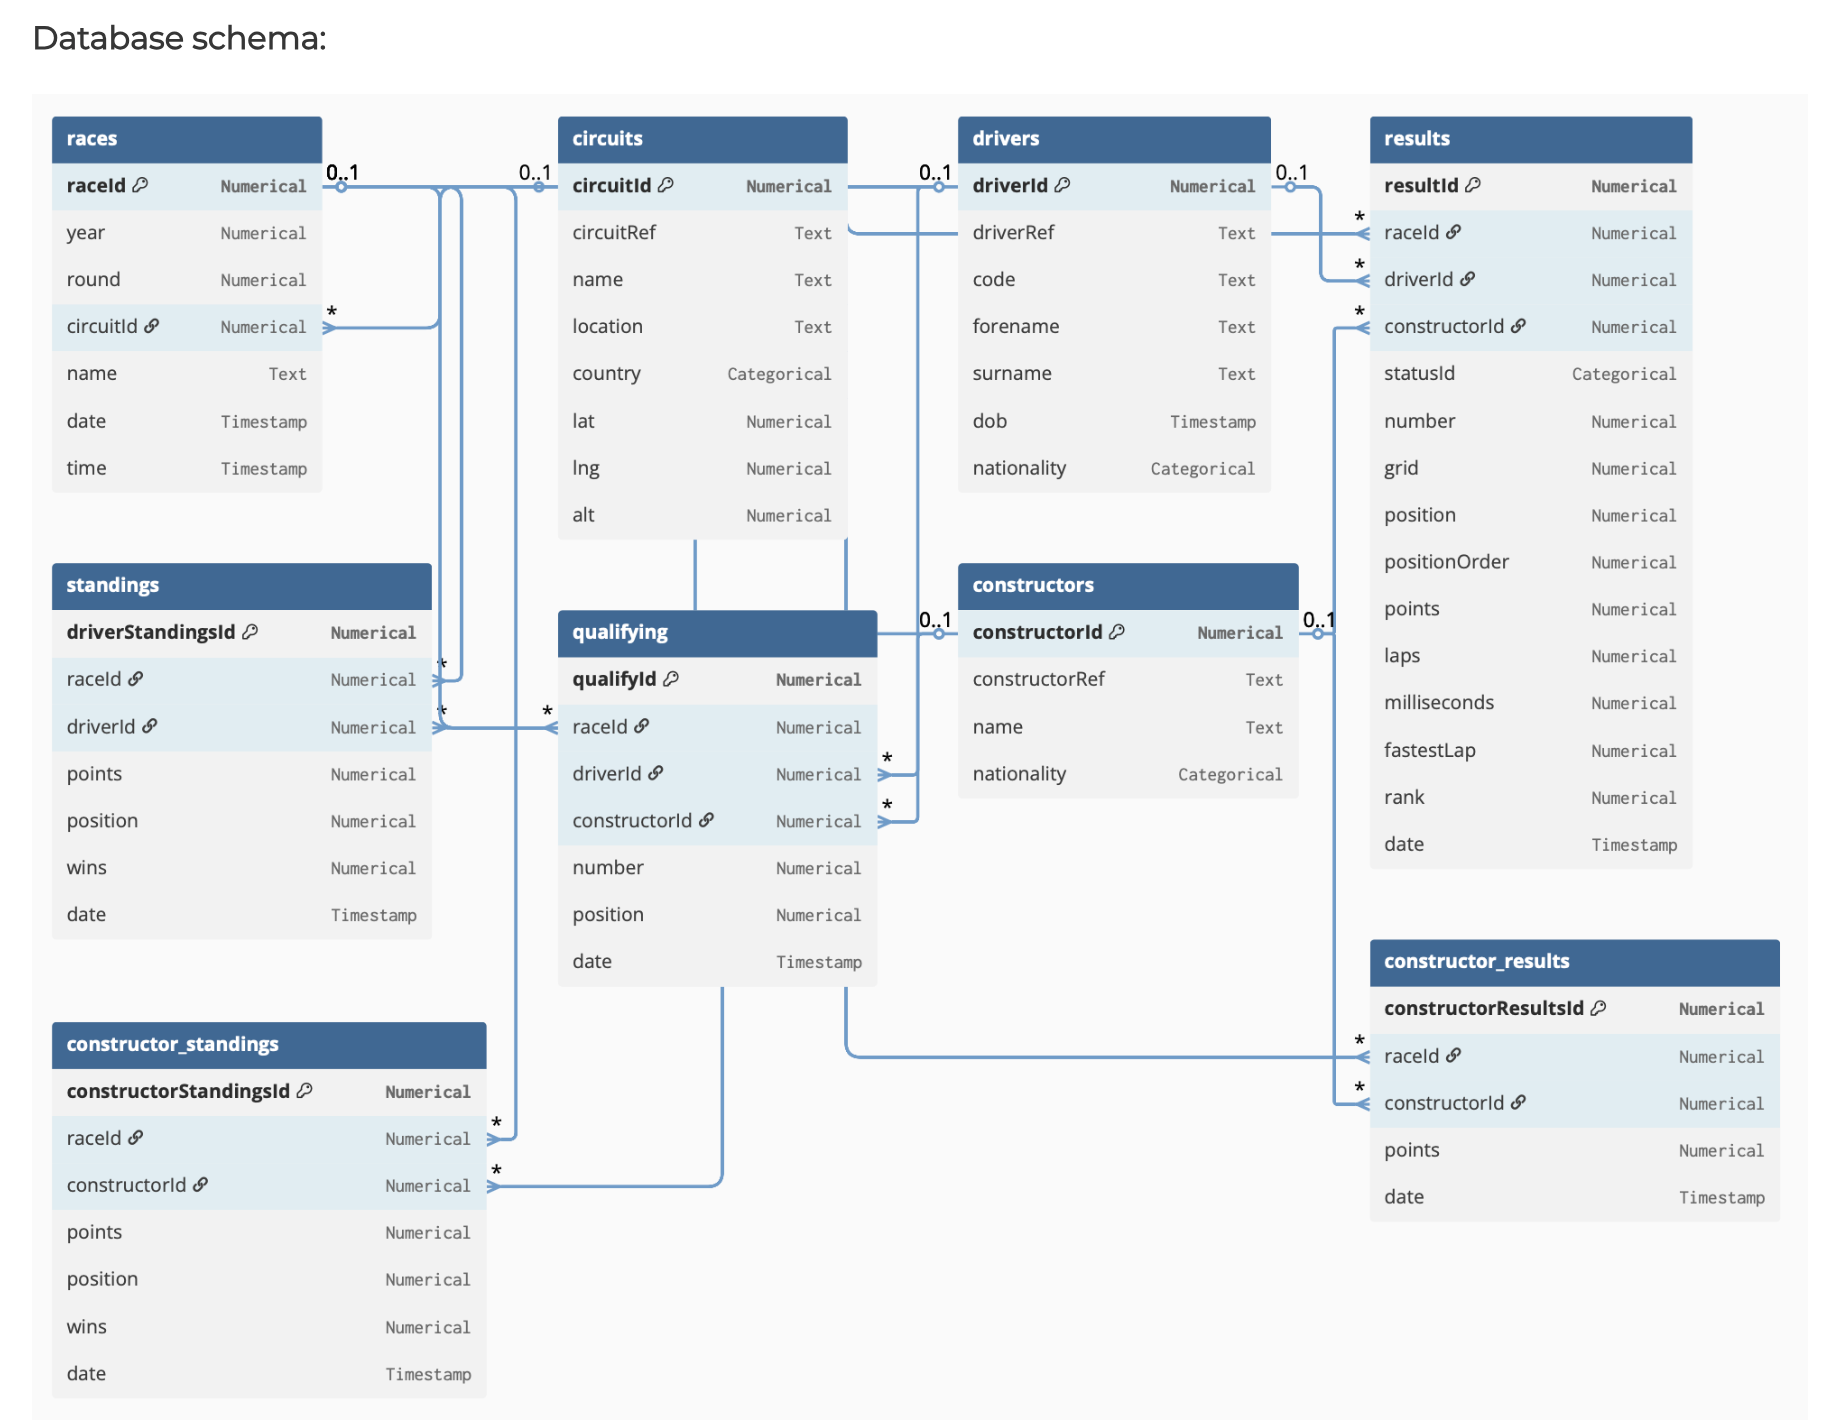

## 1. Project Objective

In this project, I compare classical machine learning methods with a graph-based relational deep learning model on the RelBench `rel-f1` dataset.

More specifically, I aim to predict a driver's finishing position by using the relational structure of Formula 1 data. In addition to a graph neural network model, I also implement and evaluate simpler baseline models. This allows me to provide a more comprehensive analysis of whether relational deep learning offers an advantage over traditional approaches.

I designed the project to be practical, reproducible, and feasible in a standard Google Colab environment.

## 2. Dataset and Task

In this project, I use the RelBench `rel-f1` dataset, which contains relational Formula 1 data stored across multiple connected tables. These tables include information about drivers, races, results, constructors, standings, circuits, and qualifying records.

Because the dataset is relational, I found it suitable for studying how machine learning and deep learning models can use structured multi-table information instead of working only with a single flat table.

I selected the `driver-position` prediction task. This is a regression task in which the objective is to predict a driver's average finishing position over a future time window. Therefore, the target variable is continuous, not categorical.

I considered this task appropriate for the project because it allows direct comparison between traditional feature-based models and graph-based relational deep learning models.

## 3. Environment Setup

I implemented this project in Google Colab by using Python and the RelBench framework. The main libraries used in this project include PyTorch, PyTorch Geometric, PyTorch Frame, and RelBench.

To support reproducibility, I fixed random seeds where possible. I also kept the implementation compatible with the hardware limitations of the free Colab environment.

During development, I encountered some compatibility issues when attempting to use external text embedding components. For this reason, I simplified the final pipeline to ensure stable execution and completion of the project.

In [ ]:
!pip uninstall -y torchaudio torchvision torchtext
!pip install -q torch==2.8.0
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.8.0+cu128.html
!pip install -q torch-geometric
!pip install -q pytorch-frame
!pip install -q relbench

In [3]:
import torch
import torch_geometric

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyG version:", torch_geometric.__version__)

Torch version: 2.8.0+cu128
CUDA available: True
PyG version: 2.7.0


In [4]:
import copy
import random
import warnings
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from relbench.datasets import get_dataset
from relbench.tasks import get_task

warnings.filterwarnings("ignore")

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 4. Data Loading and Task Splits

I loaded the dataset and task by using the RelBench API. After loading the `rel-f1` dataset, I selected the `driver-position` task. RelBench provides predefined training, validation, and test splits, and I used these splits directly in this project.

I used the predefined splits to ensure consistency and to evaluate the models under the intended task setting. I used the training split to fit the models, the validation split for model selection, and the test split only for final evaluation.

### Load dataset and task

In [6]:
dataset = get_dataset("rel-f1", download=True)
task = get_task("rel-f1", "driver-position", download=True)

db = dataset.get_db()
print("Dataset and task loaded successfully.")

  0%|                                               | 0.00/704k [00:00<?, ?B/s]

Unzipping contents of '/root/.cache/relbench/rel-f1/db.zip' to '/root/.cache/relbench/rel-f1/.'


  0%|                                              | 0.00/36.5k [00:00<?, ?B/s]

Unzipping contents of '/root/.cache/relbench/rel-f1/tasks/driver-position.zip' to '/root/.cache/relbench/rel-f1/tasks/.'


Loading Database object from /root/.cache/relbench/rel-f1/db...
Done in 0.07 seconds.
Dataset and task loaded successfully.


### Load train, validation, and test tables

In [7]:
train_table = task.get_table("train")
val_table = task.get_table("val")
test_table = task.get_table("test")

print("Train shape:", train_table.df.shape)
print("Validation shape:", val_table.df.shape)
print("Test shape:", test_table.df.shape)

Train shape: (7453, 3)
Validation shape: (499, 3)
Test shape: (760, 2)


### Preview the target tables

In [8]:
print("Train table preview:")
display(train_table.df.head())

print("Validation table preview:")
display(val_table.df.head())

print("Test table preview:")
display(test_table.df.head())

Train table preview:


,date,driverId,position
0,2004-07-05,10,10.75
1,2004-07-05,47,12.00
2,2004-03-07,7,15.00
3,2004-01-07,10,9.00
4,2003-09-09,52,13.00


Validation table preview:


,date,driverId,position
0,2009-08-08,7,4.200000
1,2009-06-09,11,12.333333
2,2009-06-09,0,11.666667
3,2009-04-10,5,15.600000
4,2009-04-10,17,1.400000


Test table preview:


,date,driverId
0,2016-05-29,835
1,2016-03-30,3
2,2016-03-30,807
3,2016-03-30,831
4,2016-01-30,830


### Check target column and basic info

In [9]:
print("Target column:", task.target_col)
print("Task type: regression")
print("Evaluation metric: MAE")

Target column: position
Task type: regression
Evaluation metric: MAE


**Data Loading Comment:**  
I loaded the `rel-f1` dataset and selected the `driver-position` task from RelBench. I used the predefined training, validation, and test splits provided by the benchmark. Since the target is continuous, I treated this problem as a regression task and planned to evaluate the models mainly with mean absolute error (MAE).

## 5. Graph Construction

A key part of this project was converting the relational database into a heterogeneous graph representation. In this graph, different tables became different node types, and primary key / foreign key relationships became edges between nodes.

This representation allowed the model to learn not only from the features of individual records, but also from the relationships between entities such as drivers, races, constructors, and results.

At first, I also considered using text embedding for text-based columns. However, I encountered compatibility issues in Google Colab when using external sentence embedding components. To keep the project stable and feasible, I simplified these text-based columns during graph construction instead of relying on additional text embedding modules.

This simplification made it possible for me to continue the project with a working end-to-end relational graph pipeline.

### Imports for graph construction

In [11]:
import os
import shutil

from relbench.modeling.utils import get_stype_proposal
from relbench.modeling.graph import make_pkey_fkey_graph
from torch_frame import stype

### Define cache directory

In [12]:
root_dir = "./data"
cache_dir = os.path.join(root_dir, "rel-f1_materialized_cache")

os.makedirs(root_dir, exist_ok=True)
print("Cache directory:", cache_dir)

Cache directory: ./data/rel-f1_materialized_cache


### Get proposed column types

In [ ]:
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

### Simplify text_embedded columns

In [ ]:
for table_name, col_dict in col_to_stype_dict.items():
    for col_name, col_st in list(col_dict.items()):
        if col_st == stype.text_embedded:
            col_to_stype_dict[table_name][col_name] = stype.categorical

print("Text columns were simplified to categorical for a stable pipeline.")

Text columns were simplified to categorical for a stable pipeline.


### Remove old cache if it exists

In [ ]:
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Old cache removed.")
else:
    print("No old cache found.")

No old cache found.


### Build heterogeneous graph

In [ ]:
data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict=col_to_stype_dict,
    cache_dir=cache_dir,
)

print(type(data))
print(data)

<class 'torch_geometric.data.hetero_data.HeteroData'>
HeteroData(
  qualifying={
    tf=TensorFrame([4082, 3]),
    time=[4082],
  },
  circuits={ tf=TensorFrame([77, 7]) },
  constructor_standings={
    tf=TensorFrame([10170, 4]),
    time=[10170],
  },
  races={
    tf=TensorFrame([820, 5]),
    time=[820],
  },
  results={
    tf=TensorFrame([20323, 11]),
    time=[20323],
  },
  constructor_results={
    tf=TensorFrame([9408, 2]),
    time=[9408],
  },
  constructors={ tf=TensorFrame([211, 3]) },
  standings={
    tf=TensorFrame([28115, 4]),
    time=[28115],
  },
  drivers={ tf=TensorFrame([857, 6]) },
  (qualifying, f2p_raceId, races)={ edge_index=[2, 4082] },
  (races, rev_f2p_raceId, qualifying)={ edge_index=[2, 4082] },
  (qualifying, f2p_driverId, drivers)={ edge_index=[2, 4082] },
  (drivers, rev_f2p_driverId, qualifying)={ edge_index=[2, 4082] },
  (qualifying, f2p_constructorId, constructors)={ edge_index=[2, 4082] },
  (constructors, rev_f2p_constructorId, qualifying)={ e

### Inspect one node type

In [ ]:
print(data["races"].tf)

TensorFrame(
  num_cols=5,
  num_rows=820,
  categorical (2): ['name', 'year'],
  numerical (1): ['round'],
  timestamp (2): ['date', 'time'],
  has_target=False,
  device='cpu',
)


### Inspect graph structure

In [ ]:
print("Node types:", data.node_types)
print("Edge types:", data.edge_types)

Node types: ['qualifying', 'circuits', 'constructor_standings', 'races', 'results', 'constructor_results', 'constructors', 'standings', 'drivers']
Edge types: [('qualifying', 'f2p_raceId', 'races'), ('races', 'rev_f2p_raceId', 'qualifying'), ('qualifying', 'f2p_driverId', 'drivers'), ('drivers', 'rev_f2p_driverId', 'qualifying'), ('qualifying', 'f2p_constructorId', 'constructors'), ('constructors', 'rev_f2p_constructorId', 'qualifying'), ('constructor_standings', 'f2p_raceId', 'races'), ('races', 'rev_f2p_raceId', 'constructor_standings'), ('constructor_standings', 'f2p_constructorId', 'constructors'), ('constructors', 'rev_f2p_constructorId', 'constructor_standings'), ('races', 'f2p_circuitId', 'circuits'), ('circuits', 'rev_f2p_circuitId', 'races'), ('results', 'f2p_raceId', 'races'), ('races', 'rev_f2p_raceId', 'results'), ('results', 'f2p_driverId', 'drivers'), ('drivers', 'rev_f2p_driverId', 'results'), ('results', 'f2p_constructorId', 'constructors'), ('constructors', 'rev_f2p_co

**Graph Construction Comment:**  
I converted the relational database into a heterogeneous graph using the primary key and foreign key relationships defined in the dataset. During this step, I simplified text-embedded columns into categorical columns to avoid compatibility problems and to keep the pipeline stable in Google Colab. This allowed me to construct a working graph representation that could be used for relational deep learning.

### Imports for loader preparation

In [ ]:
from relbench.modeling.graph import get_node_train_table_input
from torch_geometric.loader import NeighborLoader

### Build loaders for train, validation, and test

In [ ]:
loader_dict = {}

for split, table in [("train", train_table), ("val", val_table), ("test", test_table)]:
    table_input = get_node_train_table_input(
        table=table,
        task=task,
    )

    loader_dict[split] = NeighborLoader(
        data,
        num_neighbors=[128, 128],
        time_attr="time",
        input_nodes=table_input.nodes,
        input_time=table_input.time,
        transform=table_input.transform,
        batch_size=512,
        temporal_strategy="uniform",
        shuffle=(split == "train"),
        num_workers=0,
        persistent_workers=False,
    )

print("Neighbor loaders created successfully.")

Neighbor loaders created successfully.


### Inspect one training batch

In [ ]:
import pyg_lib
import torch_sparse

print("pyg_lib OK")
print("torch_sparse OK")

pyg_lib OK
torch_sparse OK


In [ ]:
train_batch = next(iter(loader_dict["train"]))
print(train_batch)

HeteroData(
  qualifying={
    tf=TensorFrame([1847, 3]),
    time=[1847],
    n_id=[1847],
    batch=[1847],
    num_sampled_nodes=[3],
  },
  circuits={
    tf=TensorFrame([0, 7]),
    n_id=[0],
    batch=[0],
    num_sampled_nodes=[3],
  },
  constructor_standings={
    tf=TensorFrame([0, 4]),
    time=[0],
    n_id=[0],
    batch=[0],
    num_sampled_nodes=[3],
  },
  races={
    tf=TensorFrame([21826, 5]),
    time=[21826],
    n_id=[21826],
    batch=[21826],
    num_sampled_nodes=[3],
  },
  results={
    tf=TensorFrame([18366, 11]),
    time=[18366],
    n_id=[18366],
    batch=[18366],
    num_sampled_nodes=[3],
  },
  constructor_results={
    tf=TensorFrame([0, 2]),
    time=[0],
    n_id=[0],
    batch=[0],
    num_sampled_nodes=[3],
  },
  constructors={
    tf=TensorFrame([1378, 3]),
    n_id=[1378],
    batch=[1378],
    num_sampled_nodes=[3],
  },
  standings={
    tf=TensorFrame([20785, 4]),
    time=[20785],
    n_id=[20785],
    batch=[20785],
    num_sampled_nodes=[

**Loader Preparation Comment:**  
I prepared mini-batch neighborhood loaders for the training, validation, and test splits. This step is important because the full relational graph is too large to process at once. By sampling local neighborhoods around the target nodes, I was able to train the graph model efficiently in Google Colab.

## 6. Baseline Models

Before training the relational graph model, I decided to build several baseline models for comparison. Since this is a deep learning project, I wanted the analysis to include not only a classical machine learning model, but also a standard deep learning model trained on flat tabular features.

The purpose of these baseline models is to understand how much predictive performance can be achieved without using the full relational graph structure. This makes the final comparison more meaningful and allows me to evaluate whether relational deep learning provides an advantage over simpler alternatives.

For this project, I used the following baseline approaches:

1. **Mean Baseline**  
   This model predicts a constant value based on the training targets. It serves as a simple reference point and shows the minimum level of performance expected from a naive approach.

2. **Random Forest Regressor**  
   This is a classical machine learning model trained on manually engineered flat features. It can capture nonlinear relationships and provides a stronger traditional baseline than a simple linear model.

3. **MLP Regressor**  
   This model is a standard deep learning approach trained on the same engineered flat features used by the Random Forest model. Including this model allows me to compare classical machine learning, standard deep learning, and relational deep learning within the same project.

Together, these baseline models provide a structured comparison framework. They help show whether the graph-based relational model learns additional information beyond what can be captured by flat feature engineering alone.

### Build flat baseline features from target tables

In [ ]:
train_df = train_table.df.copy()
val_df = val_table.df.copy()
test_df = test_table.df.copy()

all_target_df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="val"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (7453, 3)
Validation shape: (499, 3)
Test shape: (760, 2)


### Create simple driver-level historical features

In [ ]:
driver_history = train_df.groupby("driverId").agg(
    driver_mean_position=("position", "mean"),
    driver_std_position=("position", "std"),
    driver_min_position=("position", "min"),
    driver_max_position=("position", "max"),
    driver_num_races=("position", "count"),
).reset_index()

driver_history["driver_std_position"] = driver_history["driver_std_position"].fillna(0)

display(driver_history.head())

,driverId,driver_mean_position,driver_std_position,driver_min_position,driver_max_position,driver_num_races
0,1,12.504000,3.427555,6.250000,19.50,25
1,3,10.074444,4.728703,3.000000,17.25,15
2,7,10.629167,4.922590,2.666667,21.50,20
3,9,11.000000,5.656854,7.000000,15.00,2
4,10,10.681818,3.254232,5.000000,15.50,11


### Merge features into train, val, and test sets

In [ ]:
train_baseline = train_df.merge(driver_history, on="driverId", how="left")
val_baseline = val_df.merge(driver_history, on="driverId", how="left")
test_baseline = test_df.merge(driver_history, on="driverId", how="left")

feature_cols = [
    "driver_mean_position",
    "driver_std_position",
    "driver_min_position",
    "driver_max_position",
    "driver_num_races",
]

for df in [train_baseline, val_baseline, test_baseline]:
    for col in feature_cols:
        df[col] = df[col].fillna(train_baseline[col].mean())

print("Train baseline shape:", train_baseline.shape)
print("Validation baseline shape:", val_baseline.shape)
print("Test baseline shape:", test_baseline.shape)

Train baseline shape: (7453, 8)
Validation baseline shape: (499, 8)
Test baseline shape: (760, 7)


### Prepare X and y

In [ ]:
X_train = train_baseline[feature_cols].copy()
y_train = train_baseline["position"].copy()

X_val = val_baseline[feature_cols].copy()
y_val = val_baseline["position"].copy()

X_test = test_baseline[feature_cols].copy()

### Mean baseline

In [ ]:
mean_pred_value = y_train.mean()

val_pred_mean = np.full(len(X_val), mean_pred_value)

mean_val_mae = mean_absolute_error(y_val, val_pred_mean)
mean_val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_mean))
mean_val_r2 = r2_score(y_val, val_pred_mean)

print("Mean Baseline Validation Metrics")
print("MAE :", round(mean_val_mae, 4))
print("RMSE:", round(mean_val_rmse, 4))
print("R2  :", round(mean_val_r2, 4))

Mean Baseline Validation Metrics
MAE : 4.3344
RMSE: 5.4255
R2  : -0.3695


### Random Forest baseline

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)

val_pred_rf = rf_model.predict(X_val)

rf_val_mae = mean_absolute_error(y_val, val_pred_rf)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_rf))
rf_val_r2 = r2_score(y_val, val_pred_rf)

print("Random Forest Validation Metrics")
print("MAE :", round(rf_val_mae, 4))
print("RMSE:", round(rf_val_rmse, 4))
print("R2  :", round(rf_val_r2, 4))

Random Forest Validation Metrics
MAE : 3.7063
RMSE: 4.5931
R2  : 0.0185


### Define a simple PyTorch MLP baseline

In [ ]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)

X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)

In [ ]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
mlp_model = MLPRegressor(input_dim=X_train.shape[1]).to(device)
mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)
mlp_loss_fn = nn.MSELoss()

### Train the MLP baseline

In [ ]:
num_epochs = 200

for epoch in range(num_epochs):
    mlp_model.train()
    mlp_optimizer.zero_grad()

    pred = mlp_model(X_train_tensor)
    loss = mlp_loss_fn(pred, y_train_tensor)

    loss.backward()
    mlp_optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 50/200, Loss: 30.5813
Epoch 100/200, Loss: 29.5862
Epoch 150/200, Loss: 28.8938
Epoch 200/200, Loss: 28.5536


### Evaluate the MLP baseline

In [ ]:
mlp_model.eval()
with torch.no_grad():
    val_pred_mlp = mlp_model(X_val_tensor).cpu().numpy().flatten()

mlp_val_mae = mean_absolute_error(y_val, val_pred_mlp)
mlp_val_rmse = np.sqrt(mean_squared_error(y_val, val_pred_mlp))
mlp_val_r2 = r2_score(y_val, val_pred_mlp)

print("MLP Validation Metrics")
print("MAE :", round(mlp_val_mae, 4))
print("RMSE:", round(mlp_val_rmse, 4))
print("R2  :", round(mlp_val_r2, 4))

MLP Validation Metrics
MAE : 3.7553
RMSE: 4.6405
R2  : -0.0019


### Compare baseline results

In [ ]:
baseline_results = pd.DataFrame({
    "Model": ["Mean Baseline", "Random Forest", "MLP"],
    "Validation MAE": [mean_val_mae, rf_val_mae, mlp_val_mae],
    "Validation RMSE": [mean_val_rmse, rf_val_rmse, mlp_val_rmse],
    "Validation R2": [mean_val_r2, rf_val_r2, mlp_val_r2],
})

baseline_results

,Model,Validation MAE,Validation RMSE,Validation R2
0,Mean Baseline,4.334385,5.425462,-0.369534
1,Random Forest,3.706259,4.593106,0.018450
2,MLP,3.755330,4.640538,-0.001927


**Baseline Results Comment:**  
As shown above, the Mean Baseline produced the weakest validation performance, with the highest MAE and RMSE and a clearly negative R² value. The Random Forest model achieved the best baseline performance, reducing the validation MAE from **4.3344** to **3.7063** and improving RMSE from **5.4255** to **4.5931**. The MLP baseline also improved over the Mean Baseline, with a validation MAE of **3.7553**, but it performed slightly worse than the Random Forest model. Overall, these results suggest that simple historical driver-level features are useful for prediction, and that the Random Forest model was the strongest flat-feature baseline in this stage of the project.

## 7. Graph Neural Network Model

As the main model of this project, I used a graph neural network based on the RelBench tutorial pipeline. This model was designed for heterogeneous relational data and is more suitable than flat models for learning from multiple connected tables.

The model includes several main components. First, an encoder transforms the node features from different tables into a common hidden representation. Next, a temporal encoder incorporates time-related information so that the model can use temporal patterns in the data. After that, a HeteroGraphSAGE layer performs message passing across the heterogeneous graph, allowing information to flow between related entities such as drivers, races, constructors, and results. Finally, an MLP prediction head produces the final regression output.

I selected this model because it directly uses the relational structure of the dataset instead of reducing the problem to only manually engineered flat features. This makes it the most important model in the project and the main deep learning approach for final evaluation.

### GNN model imports

In [ ]:
from typing import Any, Dict, List

from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType

from relbench.modeling.nn import (
    HeteroEncoder,
    HeteroGraphSAGE,
    HeteroTemporalEncoder,
)

### Define the graph model

In [ ]:
class Model(torch.nn.Module):
    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        shallow_list: List[NodeType] = [],
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )

        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )

        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )

        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )

        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)

        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### Initialize the model

In [ ]:
model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=2,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)

print(model)

Model(
  (encoder): HeteroEncoder(
    (encoders): ModuleDict(
      (qualifying): ResNet(
        (encoder): StypeWiseFeatureEncoder(
          (encoder_dict): ModuleDict(
            (numerical): LinearEncoder()
            (timestamp): TimestampEncoder(
              (positional_encoding): PositionalEncoding()
              (cyclic_encoding): CyclicEncoding()
            )
          )
        )
        (backbone): Sequential(
          (0): FCResidualBlock(
            (lin1): Linear(in_features=384, out_features=128, bias=True)
            (lin2): Linear(in_features=128, out_features=128, bias=True)
            (relu): ReLU()
            (dropout): Dropout(p=0.2, inplace=False)
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (shortcut): Linear(in_features=384, out_features=128, bias=True)
          )
          (1): FCResidualBlock(
            (lin1): Linear(in_features

### **GNN Model Comment:**  
I used a heterogeneous graph neural network based on the RelBench tutorial design. The model includes a feature encoder, a temporal encoder, GraphSAGE message passing layers, and an MLP prediction head. This architecture allows the model to use both node attributes and relational structure when predicting driver finishing position.

**Model Design Note:**  
For the main relational deep learning model, I used the RelBench tutorial architecture as a reliable reference implementation. Instead of proposing a completely new graph architecture, I focused on building a clean experimental pipeline and performing a comprehensive comparison across baseline, classical machine learning, standard deep learning, and relational deep learning models.

## 8. Training Procedure

I trained the models by using the predefined training split and selected the best model based on validation performance. After each training epoch, I evaluated the model on the validation set and kept the model state that produced the best validation metric.

For the graph neural network model, I used mini-batch neighborhood sampling through `NeighborLoader`, which made training feasible in Google Colab. I selected the loss function and optimization settings according to the regression task, and after training, I reloaded the best model state based on validation performance.

For the baseline models, I used the same train, validation, and test split logic wherever possible. This made the comparison more consistent across different model families.

### Define loss, optimizer, and training settings

In [ ]:
loss_fn = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

epochs = 10
tune_metric = "mae"
higher_is_better = False

### Define training function

In [ ]:
def train() -> float:
    model.train()

    loss_accum = 0
    count_accum = 0

    for batch in loader_dict["train"]:
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(batch, task.entity_table)
        pred = pred.view(-1) if pred.size(1) == 1 else pred

        loss = loss_fn(pred.float(), batch[task.entity_table].y.float())
        loss.backward()
        optimizer.step()

        loss_accum += loss.detach().item() * pred.size(0)
        count_accum += pred.size(0)

    return loss_accum / count_accum

### Define evaluation function

In [ ]:
@torch.no_grad()
def test(loader) -> np.ndarray:
    model.eval()

    pred_list = []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch, task.entity_table)
        pred = pred.view(-1) if pred.size(1) == 1 else pred
        pred_list.append(pred.detach().cpu())

    return torch.cat(pred_list, dim=0).numpy()

### Train the GNN model

In [ ]:
import math
best_val_metric = math.inf
best_state_dict = None

for epoch in range(1, epochs + 1):
    train_loss = train()

    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Metrics: {val_metrics}")

    if val_metrics[tune_metric] < best_val_metric:
        best_val_metric = val_metrics[tune_metric]
        best_state_dict = copy.deepcopy(model.state_dict())

Epoch 01 | Train Loss: 9.4997 | Val Metrics: {'r2': -0.40801655069034126, 'mae': 4.614109398606784, 'rmse': 5.501158645120646}
Epoch 02 | Train Loss: 6.0811 | Val Metrics: {'r2': -0.2569181549045858, 'mae': 4.1659008466966485, 'rmse': 5.197611195777539}
Epoch 03 | Train Loss: 5.5624 | Val Metrics: {'r2': 0.038467165309899576, 'mae': 3.777600100841535, 'rmse': 4.546030542928383}
Epoch 04 | Train Loss: 5.4434 | Val Metrics: {'r2': 0.024578976406395392, 'mae': 3.7491040681470773, 'rmse': 4.578743820618303}
Epoch 05 | Train Loss: 5.3997 | Val Metrics: {'r2': 0.03365468974553032, 'mae': 3.7128004866595576, 'rmse': 4.5573927938890675}
Epoch 06 | Train Loss: 5.3576 | Val Metrics: {'r2': 0.10476285790710382, 'mae': 3.6232059625282873, 'rmse': 4.386512140620848}
Epoch 07 | Train Loss: 5.0228 | Val Metrics: {'r2': 0.2380869255877941, 'mae': 3.244304073501923, 'rmse': 4.046718573351429}
Epoch 08 | Train Loss: 4.8750 | Val Metrics: {'r2': 0.11608025555459855, 'mae': 3.636593866125297, 'rmse': 4.35

### Load best model and evaluate on validation set

In [ ]:
model.load_state_dict(best_state_dict)

val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)

print("Best validation metrics:", val_metrics)

Best validation metrics: {'r2': 0.23547378755497583, 'mae': 3.2502113969149233, 'rmse': 4.053652161387901}


### Run final test prediction

In [ ]:
test_pred = test(loader_dict["test"])
print("Test prediction shape:", test_pred.shape)
print(test_pred[:10])

Test prediction shape: (760,)
[16.244787  8.998185 17.255795 16.4439   15.463538 16.344347  9.714609
 16.209282 16.063759 16.756287]


Training Procedure Comment:
I trained the graph neural network by using mini-batch neighborhood sampling and selected the best model based on validation MAE. Since this is a regression task, I used L1 loss during training and monitored validation performance after each epoch. After training, I reloaded the best model state and generated final predictions for the test split.

## 9. Results

In this project, I compared four approaches on the `driver-position` regression task: a Mean Baseline, a Random Forest Regressor, an MLP baseline, and a graph neural network based on the RelBench tutorial design.

The validation results showed that the graph neural network achieved the best overall performance among all models. It produced the lowest MAE and RMSE values and also achieved the highest R² score. This suggests that using the relational graph structure improved predictive performance beyond what could be captured by flat engineered features alone.

### Final comparison table

In [ ]:
final_results = pd.DataFrame({
    "Model": ["Mean Baseline", "Random Forest", "MLP", "GNN"],
    "Validation MAE": [mean_val_mae, rf_val_mae, mlp_val_mae, val_metrics["mae"]],
    "Validation RMSE": [mean_val_rmse, rf_val_rmse, mlp_val_rmse, val_metrics["rmse"]],
    "Validation R2": [mean_val_r2, rf_val_r2, mlp_val_r2, val_metrics["r2"]],
})

final_results

,Model,Validation MAE,Validation RMSE,Validation R2
0,Mean Baseline,4.334385,5.425462,-0.369534
1,Random Forest,3.706259,4.593106,0.018450
2,MLP,3.755330,4.640538,-0.001927
3,GNN,3.250211,4.053652,0.235474


**Results Comment:**  
As shown above, the graph neural network achieved the strongest validation performance among all models. Its validation MAE was **3.2502**, compared with **3.7063** for the Random Forest model, **3.7553** for the MLP, and **4.3344** for the Mean Baseline. The GNN also achieved the best RMSE (**4.0537**) and the highest R² (**0.2355**). These results suggest that the relational structure of the data provided useful predictive information beyond the flat baseline features.

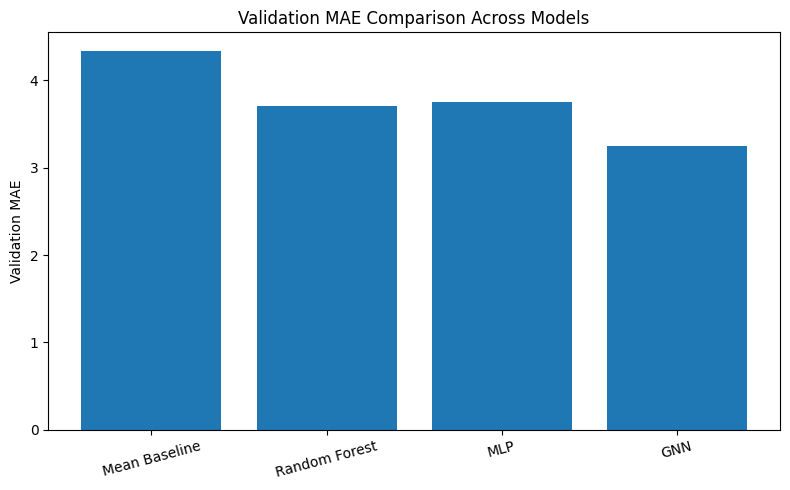

In [ ]:
import matplotlib.pyplot as plt

models = ["Mean Baseline", "Random Forest", "MLP", "GNN"]
mae_values = [4.3344, 3.7063, 3.7553, 3.2502]

plt.figure(figsize=(8, 5))
plt.bar(models, mae_values)
plt.ylabel("Validation MAE")
plt.title("Validation MAE Comparison Across Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Validation MAE comparison across models. Lower MAE indicates better prediction performance. The GNN achieved the lowest MAE among all models.


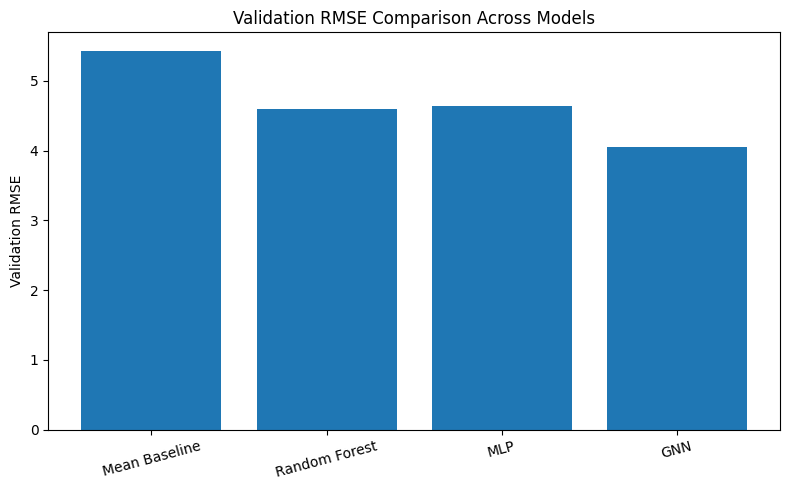

In [ ]:
import matplotlib.pyplot as plt

models = ["Mean Baseline", "Random Forest", "MLP", "GNN"]
rmse_values = [5.4255, 4.5931, 4.6405, 4.0537]

plt.figure(figsize=(8, 5))
plt.bar(models, rmse_values)
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE Comparison Across Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

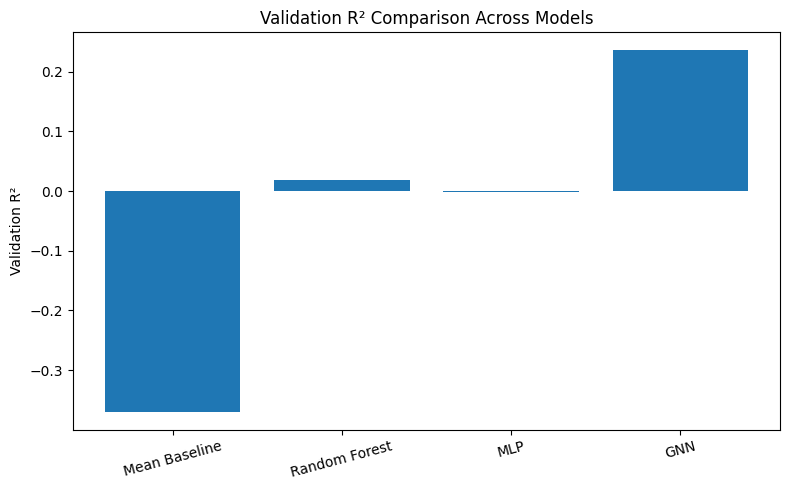

In [ ]:
import matplotlib.pyplot as plt

models = ["Mean Baseline", "Random Forest", "MLP", "GNN"]
r2_values = [-0.3695, 0.0185, -0.0019, 0.2355]

plt.figure(figsize=(8, 5))
plt.bar(models, r2_values)
plt.ylabel("Validation R²")
plt.title("Validation R² Comparison Across Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

 Validation R² comparison across models. Higher R² indicates a better fit to the target values. The GNN achieved the highest R² among all models.

## 10. Discussion

From these results, I observed that the graph neural network was the most effective model in this project. It outperformed the Mean Baseline, the Random Forest baseline, and the MLP baseline on all main validation metrics.

I also observed that the Random Forest performed better than the MLP on the flat engineered features. This suggests that a standard deep learning model does not automatically outperform a classical machine learning model when the feature set is simple and limited.

The strongest result came from the graph neural network, which directly used the relational structure of the dataset. This supports the main idea of the project: representing the database as a graph allowed the model to capture useful information that was not fully available in the flat baseline setting.

## 11. Limitations

This project has several limitations. First, to keep the experiment reproducible in a standard Google Colab environment, I used the smaller RelBench rel-f1 dataset instead of a larger benchmark such as rel-amazon. This made the project more feasible, but it also limited the scale of the experiments.

Second, I simplified the handling of text-based columns during graph construction. Instead of using a full external text embedding pipeline, I treated text-embedded columns in a simpler way to avoid compatibility problems and to keep the pipeline stable.

Third, the graph neural network model was based on the RelBench tutorial architecture rather than a completely new custom architecture. My main contribution was not proposing a new graph design, but building a complete experimental pipeline and comparing relational deep learning with multiple baseline models.

Another limitation is that hyperparameter tuning was limited.To keep the experiment computationally efficient and reproducible, I used a practical number of epochs and a limited set of design choices instead of performing a large hyperparameter search.

Finally, model comparison was based mainly on validation performance. Although final test predictions were generated, the main comparative interpretation in this notebook focused on the validation split.

## 12. Future Work

There are several ways this project could be extended in the future. One possible improvement would be to apply the same pipeline to a larger RelBench dataset if more memory and compute resources are available. This would make it possible to test whether the same conclusions hold in a larger and more complex relational setting.

Another extension would be to improve the handling of text-based columns. In a future version, I could integrate a more complete text embedding pipeline and study whether richer textual information improves graph-based prediction performance.

It would also be useful to explore additional hyperparameter tuning for both the baseline models and the graph neural network. For example, future experiments could test different hidden dimensions, neighborhood sampling sizes, numbers of layers, learning rates, and training durations.

Finally, future work could include trying alternative relational deep learning architectures and comparing them with the current GraphSAGE-based model. This would help determine whether the performance gain comes mainly from the relational graph representation itself or also from the specific model design.

## Conclusion

In this project, I explored how relational deep learning can be applied to a realistic multi-table dataset by using the RelBench `rel-f1` benchmark. My main goal was not only to train a graph neural network, but also to understand how relational data can be modeled in different ways and to compare simpler baselines with a relational deep learning approach.

To do this, I compared four models: a Mean Baseline, a Random Forest Regressor, an MLP baseline, and a graph neural network based on the RelBench tutorial design. This comparison allowed me to evaluate the problem from multiple perspectives, including naive prediction, classical machine learning, standard deep learning on flat features, and relational deep learning on graph-structured data.

The results showed that the graph neural network achieved the best validation performance among all models. This suggests that representing the database as a heterogeneous graph provided useful information that could not be fully captured by flat feature engineering alone. In other words, the relational structure itself contributed to better prediction.

From a data science perspective, this project was especially valuable because most real-world data is stored in relational databases rather than in a single flat table. In practice, data scientists often spend a large amount of time preparing, joining, and flattening data before modeling. By using RelBench, I was able to work directly with a relational benchmark and focus on how connected tables can be used for machine learning and deep learning in a more structured way.

I also found that RelBench was a very useful framework for learning and experimenting with relational deep learning. It provided a realistic dataset, predefined tasks, and a benchmark structure that made it easier to study this area without spending excessive time on raw dataset collection and manual benchmark design.

Overall, this project helped me better understand the difference between flat-feature modeling and relational deep learning. It also gave me practical experience in building, comparing, and evaluating multiple models in a structured way. For me, this project was not only about obtaining a final result, but also about learning how relational databases and deep learning can be connected in a meaningful data science workflow.

## References

- RelBench documentation: https://relbench.stanford.edu/
- RelBench rel-f1 dataset: https://relbench.stanford.edu/datasets/rel-f1/
- Robinson, J., Ranjan, R., Hu, W., Huang, K., Han, J., Dobles, A., Fey, M., Lenssen, J. E., Yuan, Y., Zhang, Z., He, X., & Leskovec, J. (2024). RelBench: A benchmark for deep learning on relational databases. arXiv: https://arxiv.org/abs/2407.20060
- PyTorch Geometric documentation: https://pytorch-geometric.readthedocs.io/